Importación de Librerias

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

Lectura y Cargue de la infromación

In [124]:
df = pd.read_csv("insurance.csv")

print("\nPrimeras filas del dataset:")
df.head()


Primeras filas del dataset:


,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01


Obtención de la información de los datos

In [125]:
print("\nInformacion del dataset:")
df.info()


Informacion del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   str    
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   str    
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   str    
 8   region         1337 non-null   str    
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), str(4)
memory usage: 104.8 KB


Configuración del Formato de los Datos

In [126]:
pd.set_option("display.float_format","{:.2f}".format)

df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.30,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.70,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.10,100,No,0,No,northwest,1137.01
...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87


Revisión  de datos nulos

In [127]:
print("\nValores nulos:")
df.isna().sum()


Valores nulos:


Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

Limpieza de Datos Nulos

In [128]:
print("\nLimpieza de datos nulos:")
df.dropna(inplace = True)
df. shape


Limpieza de datos nulos:


(1332, 10)

Revisión de datos duplicados

In [129]:
df.duplicated().sum()

np.int64(0)

Generación de estadisticas de los datos

In [130]:
print("\nEstadisticas:")
df.describe(include="all")


Estadisticas:


,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


Estandarización de la interfaz

In [131]:
sns.set(style="whitegrid", palette="Set2", font_scale= 1.1)

Graficación de los datos

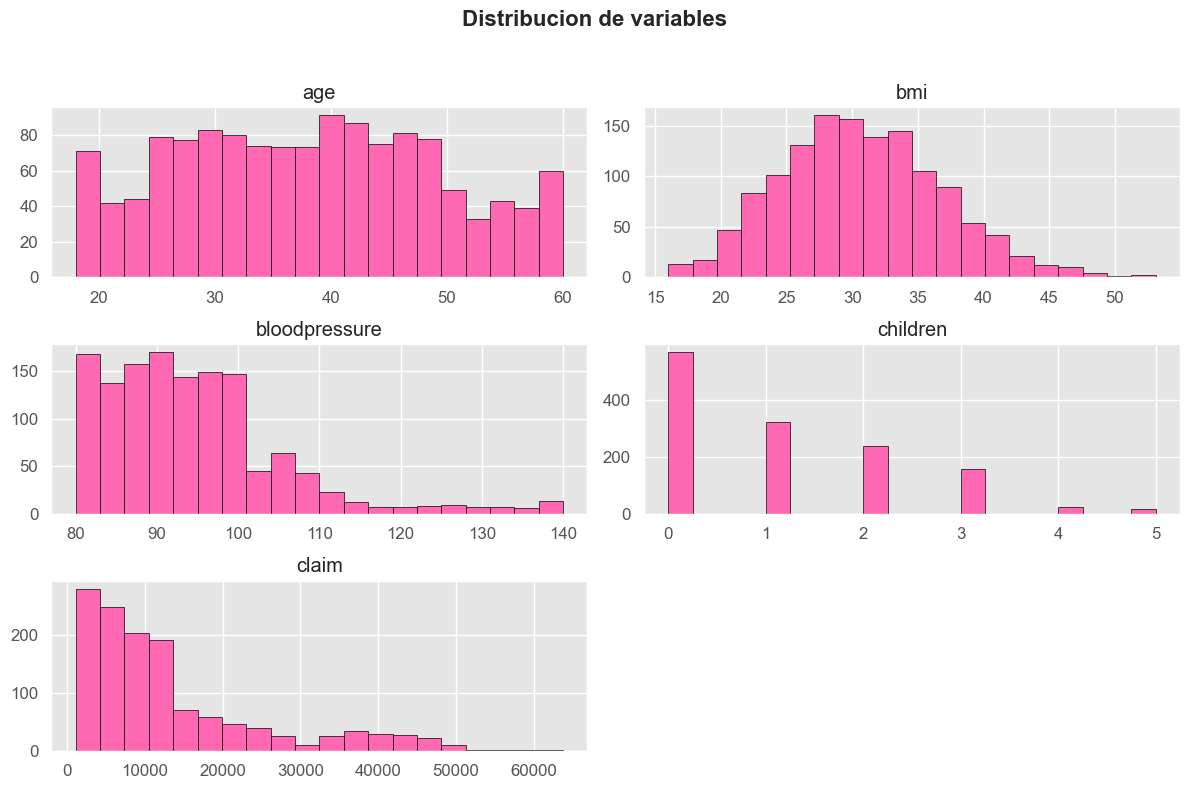

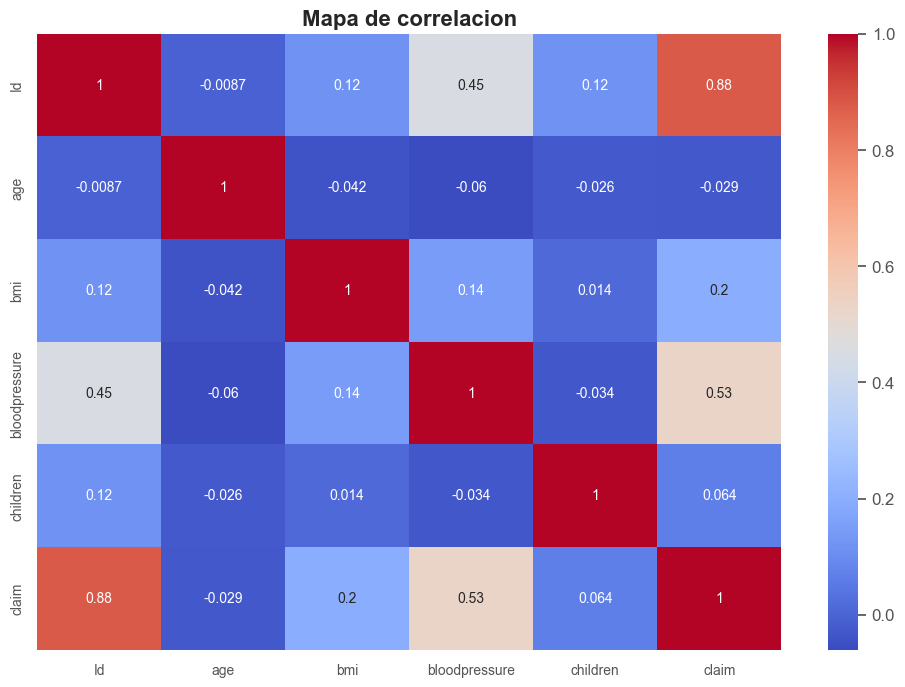

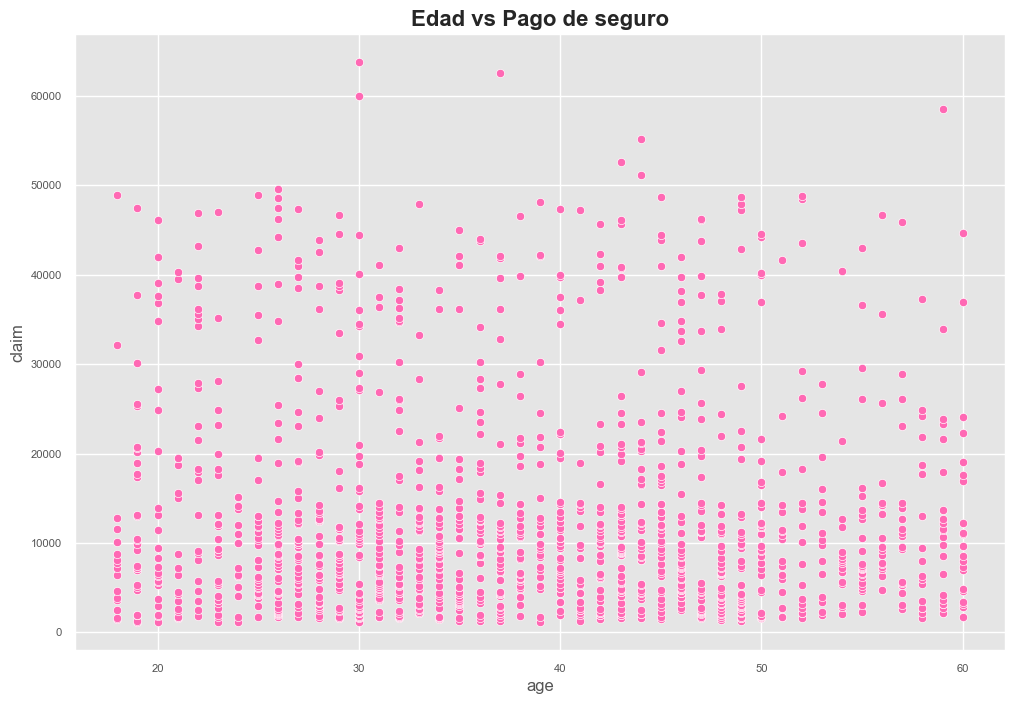

In [152]:
#Configuración del histograma para los datos numericos
plt.style.use("ggplot")
df.drop("Id", axis=1).hist(
    figsize=(12,8),
    bins=20,
    layout=(3,2),
    edgecolor="black",
    color="hotpink"
)

plt.suptitle("Distribucion de variables", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

#Configuración del mosaico para los datos Categoricos
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.tick_params(axis='both', labelsize=10)
plt.title("Mapa de correlacion", fontsize=16, fontweight="bold")
plt.show()

#Configuración del Grafico de dispersion
plt.figure(figsize=(12,8))
sns.scatterplot(x="age", y="claim", data=df, color = "hotpink")

plt.tick_params(axis='both', which='major', labelsize=8)
plt.title("Edad vs Pago de seguro", fontsize=16, fontweight="bold")
plt.show()

In [ ]:
#Configuración del histograma comparativo
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.tick_params(axis='both', labelsize=10)
plt.title("Mapa de correlacion", fontsize=16, fontweight="bold")
plt.show()

#Configuración del Grafico de dispersion
plt.figure(figsize=(12,8))
sns.scatterplot(x="age", y="claim", data=df, color = "hotpink")

plt.tick_params(axis='both', which='major', labelsize=8)
plt.title("Edad vs Pago de seguro", fontsize=16, fontweight="bold")
plt.show()

In [ ]:
X = df.drop("claim", axis=1)
y = df["claim"]

In [ ]:
le = LabelEncoder()

categorical_columns = ["gender", "smoker", "diabetic", "region"]

for col in categorical_columns:
    X[col] = le.fit_transform(X[col])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
r2_lr = r2_score(y_test, pred_lr)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))

print("\nResultados Linear Regression")
print("R2:", r2_lr)
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)


Resultados Linear Regression
R2: 0.8798631619177464
MAE: 2922.492469709988
RMSE: 4161.209747395553


In [ ]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [ ]:
r2_rf = r2_score(y_test, pred_rf)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

print("\nResultados Random Forest")
print("R2:", r2_rf)
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)


Resultados Random Forest
R2: 0.9998823481268592
MAE: 42.95314044943822
RMSE: 130.22097161181438


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [r2_lr, r2_rf],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf]
})

print("\nComparacion de modelos:")
print(results)


Comparacion de modelos:
               Model        R2         MAE         RMSE
0  Linear Regression  0.879863  2922.49247  4161.209747
1      Random Forest  0.999882    42.95314   130.220972


In [ ]:
best_model = results.sort_values(by="R2", ascending=False)

print("\nMejor modelo:")
print(best_model.head(1))


Mejor modelo:
           Model        R2       MAE        RMSE
1  Random Forest  0.999882  42.95314  130.220972
